### Before start, load inference environments, gpu, cuda, ...

In [1]:
from envs import actenv_jupyter, change_exp_dir, make_gpu_mem_reporter
actenv_jupyter(cuda_version="12.9", gcc_version="11", clear_cache=False)

[actenv_jupyter] CUDA_HOME=/usr/local/cuda-12.9
[actenv_jupyter] TORCH_CUDA_ARCH_LIST=8.0
[actenv_jupyter] CXX=/usr/bin/g++-11 | CC=/usr/bin/gcc-11
[actenv_jupyter] Ready.


{'CUDA_HOME': '/usr/local/cuda-12.9',
 'TORCH_CUDA_ARCH_LIST': '8.0',
 'CC': '/usr/bin/gcc-11',
 'CXX': '/usr/bin/g++-11',
 'CUDAHOSTCXX': '/usr/bin/g++-11',
 'CXXFLAGS': '-std=c++17',
 'PATH_head': '/usr/local/cuda-12.9/bin:/home/ids/yuhe/anaconda3/envs/styleGANenv/bin:/home/ids/yuhe/.vscode-server/cli/servers/Stable-c3a26841a84f20dfe0850d0a5a9bd01da4f003ea/server/bin/remote-cli',
 'LD_LIBRARY_PATH_head': '/usr/local/cuda-12.9/lib64:/usr/local/cuda-12.9/lib64:$LD_LIBRARY_PATH',
 'TORCH_CUDA_VERBOSE_BUILD': '1',
 'MAX_JOBS': '1'}

### Set experiment dir and models' paths

In [2]:
import torch
import os
import yaml

root_dir = "/home/ids/yuhe/Projects/CA_with_GAN/3_code/styleGAN"
sfe_root = "/home/ids/yuhe/Projects/CA_with_GAN/3_code/styleGAN/SOTA_encoders_StyleGAN/StyleFeatureEditor-CS"
medminist_path = '/home/ids/yuhe/Projects/CA_with_GAN/2_data/medical_datasets'

Paths = {
        "base_models": {
            "stylegan_weights":  "/home/ids/yuhe/Projects/CA_with_GAN/3_code/styleGAN/pretrained_models/stylegan2/stylegan2_medical_images/brats_rosinality.pt",
            "stylegan_weights_pkl": "/home/ids/yuhe/Projects/CA_with_GAN/3_code/styleGAN/styleGAN_ada/output/brats_resume/00000-brats256x256-mirror-paper256-ada-blit-resumecustom/network-snapshot-002419.pkl",
            "pSp_path": "/home/ids/yuhe/Projects/CA_with_GAN/3_code/styleGAN/SOTA_encoders_StyleGAN/pSp/results/brats_ht_Ros_resume/checkpoints/iteration_20000.pt",
            "inverter_pth": "/home/ids/yuhe/Projects/CA_with_GAN/3_code/styleGAN/SOTA_encoders_StyleGAN/StyleFeatureEditor-CS/experiments/inverter/brats_ht/fse_inverter_train_000/iteration_140000.pt",
            "sfe_path": sfe_root + "/experiments/fse_cs_editor_train/brats_ht/brats_ht_000/iteration_370000.pt",
        },

        "wo_regular": {
        "pSp_cs_path": root_dir +  "/SOTA_encoders_StyleGAN/pSp_CS-StyleGAN/results/Regularization/wo_regular/checkpoints/iteration_100000.pt",
        "sfe_path": root_dir + "/SOTA_encoders_StyleGAN/StyleFeatureEditor-CS/experiments/fse_cs_editor_train/Regularization/wo_regular_000/iteration_430000.pt",
        },
        "with_D_only": {
        "pSp_cs_path": root_dir + "/SOTA_encoders_StyleGAN/pSp_CS-StyleGAN/results/Regularization/adv_D_start_step1000/checkpoints/iteration_100000.pt",
        "sfe_path": root_dir + "/SOTA_encoders_StyleGAN/StyleFeatureEditor-CS/experiments/fse_cs_editor_train/Regularization/adv_D_only_000/iteration_350000.pt",
        },
        "with_DR_DiscMI": {
        "pSp_cs_path": root_dir + "/SOTA_encoders_StyleGAN/pSp_CS-StyleGAN/results/Regularization/adv_DR_DiscMI/Exp4_startstep2000_Rlr0.05_Rlayer2_MLPlr0.001/checkpoints/iteration_110000.pt",
        "sfe_path": root_dir + "/SOTA_encoders_StyleGAN/StyleFeatureEditor-CS/experiments/fse_cs_editor_train/Regularization/adv_DR_DiscMI_000/iteration_430000.pt",
        },
        
        "with_DR_RegrMI_90k": {
        "pSp_cs_path": root_dir + "/SOTA_encoders_StyleGAN/pSp_CS-StyleGAN/results/Regularization/adv_DR_RegrR/Exp4_startstep2000_Rlr0.05_Rlayer2_MLPlr0.001/checkpoints/iteration_90000.pt",
        "sfe_path": root_dir + "/SOTA_encoders_StyleGAN/StyleFeatureEditor-CS/experiments/fse_cs_editor_train/Regularization/RegrR_D_90k_000/iteration_430000.pt",
        },
        
        "with_DR_RegrMI_110k": {
        "pSp_cs_path": root_dir + "/SOTA_encoders_StyleGAN/pSp_CS-StyleGAN/results/Regularization/adv_DR_RegrR/Exp4_startstep2000_Rlr0.05_Rlayer2_MLPlr0.001/checkpoints/iteration_110000.pt",
        "sfe_path": root_dir + "/SOTA_encoders_StyleGAN/StyleFeatureEditor-CS/experiments/fse_cs_editor_train/Regularization/RegrR_D_110k_000/iteration_430000.pt",
        }, 
        "with_DR_RegrMI_120k": {
        "pSp_cs_path": root_dir + "/SOTA_encoders_StyleGAN/pSp_CS-StyleGAN/results/Regularization/adv_DR_RegrR/Exp4_startstep2000_Rlr0.05_Rlayer2_MLPlr0.001/checkpoints/iteration_120000.pt",
        "sfe_path": root_dir + "/SOTA_encoders_StyleGAN/StyleFeatureEditor-CS/experiments/fse_cs_editor_train/Regularization/RegrR_D_120k_000/iteration_430000.pt",
        },
        "with_DR_RegrMI_140k": {
        "pSp_cs_path": root_dir + "/SOTA_encoders_StyleGAN/pSp_CS-StyleGAN/results/Regularization/adv_DR_RegrR/Exp4_startstep2000_Rlr0.05_Rlayer2_MLPlr0.001/checkpoints/iteration_140000.pt",
        "sfe_path": root_dir + "/SOTA_encoders_StyleGAN/StyleFeatureEditor-CS/experiments/fse_cs_editor_train/Regularization/RegrR_D_140k_000/iteration_430000.pt",
        },        
        }


change_exp_dir(sfe_root)
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

model_name = 'with_DR_RegrMI_90k'


sfe_ckpt = Paths[model_name]["sfe_path"]

# Load config.yaml
config_yaml_path = os.path.join(os.path.dirname(sfe_ckpt), "config.yaml")
from omegaconf import OmegaConf
config = OmegaConf.load(config_yaml_path)
config.model.w_space_encoder = "pSp"

config.data.dataset="brats_ht_new"
config.model.checkpoint_path = sfe_ckpt
config.model.pSp_cs_path = Paths[model_name]["pSp_cs_path"]

config.model.batch_size = 4  # Set batch size for inference

# Pretty YAML (my favorite)
from omegaconf import OmegaConf
print(OmegaConf.to_yaml(config))



cwd: /home/ids/yuhe/Projects/CA_with_GAN/3_code/styleGAN/SOTA_encoders_StyleGAN/StyleFeatureEditor-CS
Using device: cuda
exp:
  config_dir: configs
  config: fse_cs_editor_train.yaml
  exp_dir: ./experiments/
  name: fse_cs_editor_train/Regularization/RegrR_D_90k
  seed: 1
  root: .
  wandb: false
  wandb_project: sfe
  domain: human_faces
  exp_type: ffhq_glasses
data:
  data_dir: ???
  dataset: brats_ht_new
  transform: face_256
  special_idx: -1
train:
  train_runner: fse_editor_cs
  inverter_optimizer: ranger
  encoder_optimizer: ranger
  disc_optimizer: adam
  resume_path: ''
  val_metrics:
  - msssim
  - lpips
  - l2
  - fid
  start_step: 300000
  steps: 500000
  log_step: 2000
  checkpoint_step: 10000
  val_step: 2000
  train_dis: true
  train_disc_edit: false
  dis_train_start_step: 45000
  bs_used_before_adv_loss: 8
  disc_edits: []
  direction: two_directions
model:
  method: fse_full
  device: '0'
  batch_size: 4
  workers: 4
  checkpoint_path: /home/ids/yuhe/Projects/CA_wit

In [3]:
from envs import make_gpu_mem_reporter
print_memory = make_gpu_mem_reporter(gpu_index=0, clear_cache_on_setup=True)

print_memory("Before loading model")

from runners.simple_runner import SimpleRunner
runner = SimpleRunner(config=config)
sfe_model = runner.inference_runner
device = sfe_model.device

sfe_model.method.train()

print_memory("After loading model")


[Before loading model]
  - PyTorch Allocated : 0.00 GB
  - PyTorch Reserved  : 0.00 GB
  - Total GPU Used    : 0.51 GB / 40.00 GB



/home/ids/yuhe/anaconda3/envs/styleGANenv/lib/python3.11/site-packages/transformers/utils/generic.py:441: UserWarning: torch.utils._pytree._register_pytree_node is deprecated. Please use torch.utils._pytree.register_pytree_node instead.
  _torch_pytree._register_pytree_node(


Device: cuda:0
[DEBUG----------------------------] channel_multiplier = 1
[DEBUG----------------------------] stylegan_size = 256
n_styles:  14
Using pSp as w encoder, loading pSp-cs model ....
Loading pSp from checkpoint: /home/ids/yuhe/Projects/CA_with_GAN/3_code/styleGAN/SOTA_encoders_StyleGAN/pSp/results/brats_ht_Ros_resume/checkpoints/iteration_20000.pt
Loading cs mlp from path: /home/ids/yuhe/Projects/CA_with_GAN/3_code/styleGAN/SOTA_encoders_StyleGAN/pSp_CS-StyleGAN/results/Regularization/adv_DR_RegrR/Exp4_startstep2000_Rlr0.05_Rlayer2_MLPlr0.001/checkpoints/iteration_90000.pt
Loading discriminator from /home/ids/yuhe/Projects/CA_with_GAN/3_code/styleGAN/styleGAN_ada/output/brats_resume/00000-brats256x256-mirror-paper256-ada-blit-resumecustom/network-snapshot-002419.pkl
✅ pkl loaded via legacy_load
✅ adapted b256.fromrgb.weight: (64, 1, 1, 1) -> (64, 3, 1, 1) (1ch->3ch)
✅ load_disc_any(module->ada): loaded all 64 keys (no mismatch).
✅ discriminator loaded from MODULE (re-instant

In [4]:
from torchvision.utils import save_image
from utils.common_utils import tensor2im, get_keys, visualize_batch_grid
from inference_ipynb.inference_funcs import get_latents_cs, calculate_delta_by_latent, recon_by_latent_w, recon_by_delta, configure_datasets, configure_Seg_datasets, preprocess_image, get_random_seeds
import shutil
from tqdm import tqdm
import torch
import torch.nn.functional as F
import random


def maybe_crop(img, crop_cfg):
    if crop_cfg is None:
        return img
    return crop_tensor(img, **crop_cfg)

def crop_tensor(
    img,        # Tensor: [C, H, W] or [H, W]
    w_l=0,
    w_r=0,
    h_top=0,
    h_bot=0,
):
    """
    Crop tensor image.

    Args:
        img: torch.Tensor
        w_l, w_r: pixels to crop from left / right
        h_top, h_bot: pixels to crop from top / bottom
    """
    if img.dim() == 3:
        _, H, W = img.shape
        return img[:, h_top:H - h_bot, w_l:W - w_r]
    elif img.dim() == 2:
        H, W = img.shape
        return img[h_top:H - h_bot, w_l:W - w_r]
    else:
        raise ValueError(f"Unsupported tensor shape: {img.shape}")

def inference(
    sfe_model,
    test_bg_dataloader,
    test_t_dataloader,
    idx,
    vis_mode="row",
    num_pairs=4,
    target_batch_idx=None, 
    crop_cfg=None,
    seed=0
):
    """
    vis_mode:
        - 'row': paper-style visualization (X on top, Y below)
        - 'col': column-wise visualization (X/Y side by side, multiple rows)

    target_batch_idx:
        - None: use first batch (default/debug)
        - int:  use the specified batch index (reproducible)
    """

    with torch.no_grad():
        for batch_idx, (batch_bg, batch_t) in tqdm(
            enumerate(zip(test_bg_dataloader, test_t_dataloader)),
            total=len(test_bg_dataloader)
        ):
            # ----------------------------------
            # skip until target batch
            # ----------------------------------
            if target_batch_idx is not None and batch_idx != target_batch_idx:
                continue

            X = batch_bg.to(device).float()
            Y = batch_t.to(device).float()

            X_resh = F.interpolate(X, size=(256, 256), mode="bilinear", align_corners=False)
            Y_resh = F.interpolate(Y, size=(256, 256), mode="bilinear", align_corners=False)

            # ---- latent decomposition ----
            c_x, s_x, c_y, s_y = get_latents_cs(X_resh, Y_resh, sfe_model)

            # ---- recon in W space ----
            s_x_zero = torch.zeros_like(s_x)
            recon_w_X = recon_by_latent_w(c_x + s_x_zero, sfe_model)
            recon_w_Y = recon_by_latent_w(c_y + s_y, sfe_model)

            swap_w_X2Y = recon_by_latent_w(c_x + s_y, sfe_model)
            swap_w_Y2X = recon_by_latent_w(c_y + s_x_zero, sfe_model)

            # ---- recon in image (delta) space ----
            recon_f_X = recon_by_delta(X_resh, delta=None, sfe_model=sfe_model)
            recon_f_Y = recon_by_delta(Y_resh, delta=None, sfe_model=sfe_model)

            delta_x2y = calculate_delta_by_latent(c_x + s_x_zero, c_x + s_y, sfe_model)
            delta_y2x = calculate_delta_by_latent(c_y + s_y, c_y + s_x_zero, sfe_model)

            swap_f_X2Y = recon_by_delta(X_resh, delta_x2y, sfe_model)
            swap_f_Y2X = recon_by_delta(Y_resh, delta_y2x, sfe_model)

            # 👉 我们只需要一个 batch
            break

    # ==========================================================
    # Visualization
    # ==========================================================
    if vis_mode == "row":
        row1 = torch.stack(
            [
                maybe_crop(X[idx], crop_cfg),
                maybe_crop(recon_w_X[idx], crop_cfg),
                maybe_crop(swap_w_X2Y[idx], crop_cfg),
                maybe_crop(recon_f_X[idx], crop_cfg),
                maybe_crop(swap_f_X2Y[idx], crop_cfg),
            ],
            dim=0
        )

        row2 = torch.stack(
            [
                maybe_crop(Y[idx], crop_cfg),
                maybe_crop(recon_w_Y[idx], crop_cfg),
                maybe_crop(swap_w_Y2X[idx], crop_cfg),
                maybe_crop(recon_f_Y[idx], crop_cfg),
                maybe_crop(swap_f_Y2X[idx], crop_cfg),
            ],
            dim=0
        )


        columns = [torch.stack([row1[i], row2[i]], dim=0) for i in range(len(row1))]

        visualize_batch_grid(
            image_batches=columns,
            titles=[f"Input", "Recon W", "Swap W", "Recon F", "Swap F"],
            save_path=None,
            # wspace=wspace,   # 
            # hspace=hspace
        )

    elif vis_mode == "col":
        for i in range(num_pairs):
            col_X = torch.stack(
                [
                    maybe_crop(X[i], crop_cfg),
                    maybe_crop(recon_f_X[i], crop_cfg),
                    maybe_crop(swap_f_X2Y[i], crop_cfg),
                ],
                dim=0
            )

            col_Y = torch.stack(
                [
                    maybe_crop(Y[i], crop_cfg),
                    maybe_crop(recon_f_Y[i], crop_cfg),
                    maybe_crop(swap_f_Y2X[i], crop_cfg),
                ],
                dim=0
            )

            visualize_batch_grid(
                image_batches=[col_X, col_Y],
                titles=[f"X_{seed}_{i}", f"Y #{i}"],
                save_path=None,
                # wspace=wspace,   # 
                # hspace=hspace
            )

    else:
        raise ValueError(f"Unknown vis_mode: {vis_mode}")






def get_paired_random_batch(loader_X, loader_Y):
    """
    Returns one random paired batch (same batch index)
    from loader_X and loader_Y.
    """
    num_batches = len(loader_X)
    idx = random.randint(0, num_batches - 1)

    # iterate both loaders in sync
    for i, (batch_X, batch_Y) in enumerate(zip(loader_X, loader_Y)):
        if i == idx:
            return batch_X, batch_Y

    raise RuntimeError("Batch index out of range")

import numpy as np
def seed_experiments(seed):
    # Set the random seed for reproducibility
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)  # If you use multi-GPU.

    # Ensures deterministic behavior for some PyTorch operations
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False



## Latent separation evaluation

In [6]:
import os
import sys
from pathlib import Path

import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image


# ============================================================
# A1) Path setup + import load_classifier
# ============================================================
def setup_repo_and_import_loader(repo_root: str):
    repo_root = str(Path(repo_root).resolve())

    if repo_root in sys.path:
        sys.path.remove(repo_root)
    sys.path.insert(0, repo_root)

    # 清缓存，避免之前 import 指到错误模块
    for k in list(sys.modules.keys()):
        if k == "models" or k.startswith("models.") or k == "CFgenerating" or k.startswith("CFgenerating."):
            sys.modules.pop(k, None)

    from CFgenerating.model_loading import load_classifier
    return load_classifier


def load_cls(ckpt_path: str, model_type: str, device: str):
    load_classifier = setup_repo_and_import_loader("/home/ids/yuhe/Projects/CA_with_GAN/3_code/FastDiME_Med")
    cls = load_classifier(ckpt_path, model_type, device)
    cls.eval()
    return cls


# ============================================================
# A2) Preprocess: 3ch -> 1ch + (optional) PNG quantization
# ============================================================
def rgb_to_gray_luma(x: torch.Tensor) -> torch.Tensor:
    """
    x: [N,3,H,W] in [-1,1] (or any range, linear OK)
    return: [N,1,H,W]
    """
    r, g, b = x[:, 0:1], x[:, 1:2], x[:, 2:3]
    return 0.2989 * r + 0.5870 * g + 0.1140 * b


def ensure_1ch(x: torch.Tensor) -> torch.Tensor:
    """
    x: [N,C,H,W] -> [N,1,H,W]
    """
    if x.shape[1] == 1:
        return x
    if x.shape[1] == 3:
        return rgb_to_gray_luma(x)
    return x.mean(dim=1, keepdim=True)


def quantize_like_png(x: torch.Tensor) -> torch.Tensor:
    """
    模拟 classify_folder.py 的 PNG 8-bit 量化再读回：
    x: [N,1,H,W] in [-1,1]
    return: [N,1,H,W] in [-1,1]
    """
    x = x.clamp(-1, 1)
    u8 = (((x + 1) / 2) * 255.0).round().clamp(0, 255).to(torch.uint8)
    xq = (u8.float() / 255.0) * 2.0 - 1.0
    return xq


def preprocess_for_classifier(imgs: torch.Tensor, do_png_quant: bool = True) -> torch.Tensor:
    """
    imgs: [N,C,H,W] in [-1,1]  (C can be 1 or 3)
    """
    imgs = ensure_1ch(imgs)
    if do_png_quant:
        imgs = quantize_like_png(imgs)
    return imgs


# ============================================================
# A3) Batch prob for recon list
# ============================================================
@torch.no_grad()
def probs_for_recon_list(recon_list, classifier, device, t_val=0, idx_in_batch=0, do_png_quant=True):
    """
    recon_list: list of tensors, each [B,3,256,256] (or [B,1,256,256]) in [-1,1]
    """
    imgs = torch.cat([x[idx_in_batch:idx_in_batch+1] for x in recon_list], dim=0).float().to(device)  # [N,C,H,W]
    imgs = preprocess_for_classifier(imgs, do_png_quant=do_png_quant)                                  # [N,1,H,W]

    t = torch.full((imgs.shape[0],), int(t_val), device=device, dtype=torch.long)
    logits = classifier(imgs, t).view(-1)
    probs = torch.sigmoid(logits)
    return probs.detach().cpu().numpy(), logits.detach().cpu().numpy()


# ============================================================
# A4) Visualization helpers: crop + overlay + plotting
# ============================================================
def crop_image(img, w_l=0, w_r=0, h_top=0, h_bot=0):
    w, h = img.size
    return img.crop((w_l, h_top, w - w_r, h - h_bot))


def tensor_to_cropped_img(t, crop_cfg):
    """
    t: tensor [C,H,W] in [-1,1]
    return: numpy image for imshow
    """
    t = ((t.clamp(-1, 1) + 1) / 2).detach().cpu()
    if t.shape[0] == 1:
        img = (t.squeeze(0).numpy() * 255).astype("uint8")
        pil_img = Image.fromarray(img, mode="L")
    else:
        img = (t.permute(1, 2, 0).numpy() * 255).astype("uint8")
        pil_img = Image.fromarray(img)
    pil_img = crop_image(pil_img, **crop_cfg)
    return np.array(pil_img)


def add_prob_overlay(ax, prob, fontsize=14):
    ax.text(
        0.02, 0.10, f"P(tumor)={prob:.3f}",
        transform=ax.transAxes,
        ha="left", va="top",
        fontsize=fontsize,
        color="white",
        bbox=dict(facecolor="black", alpha=0.6, pad=2, edgecolor="none"),
        zorder=10,
        clip_on=True,
    )


def plot_row_with_overlay(recon_list, probs, titles, crop_cfg, figsize_scale=2.2, title_fs=18, prob_fs=14):
    num_images = len(recon_list)
    col_spacing = 0.0
    total_width = 1.0
    img_width = (total_width - (num_images - 1) * col_spacing) / num_images
    title_height = 0.10

    fig = plt.figure(figsize=(num_images * figsize_scale, 3.0))
    for i in range(num_images):
        left = i * (img_width + col_spacing)
        ax = fig.add_axes([left, 0, img_width, 1 - title_height])

        img = tensor_to_cropped_img(recon_list[i][0], crop_cfg)  # 显示 batch 第0张
        ax.imshow(img)
        ax.axis("off")

        ax.set_title(titles[i], fontsize=title_fs, pad=2)
        add_prob_overlay(ax, probs[i], fontsize=prob_fs)

    plt.show()


def plot_alpha_prob_curves(alphas, probs, title, mode="discrete"):
    """
    mode:
      - "discrete": x=0..N-1, tick labels: real, 0.0..1.0
      - "continuous": x=-0.05,0..1 (real at -0.05)
    """
    if mode == "continuous":
        x_axis = np.concatenate(([-0.05], alphas.detach().cpu().numpy()))
        plt.figure(figsize=(6,4))
        plt.plot(x_axis, probs, marker="o")
        plt.xlabel("alpha (real at -0.05)")
    else:
        xs = np.arange(len(probs))  # 0..N-1
        labels = ["real"] + [f"{a:.1f}" for a in alphas.detach().cpu().numpy()]
        plt.figure(figsize=(7,4))
        plt.plot(xs, probs, marker="o")
        plt.xticks(xs, labels)
        plt.xlabel("alpha")

    plt.ylim(0, 1)
    plt.ylabel("P(tumor)")
    plt.title(title)
    plt.grid(True)
    plt.show()



# def load_sd_classifier():
#     # ============================================================
#     # 0) Add repo to sys.path + import classifier loader
#     # ============================================================
#     PROJECT_ROOT = Path("/home/ids/yuhe/Projects/CA_with_GAN/3_code/FastDiME_Med").resolve()

#     # 确保项目根目录在 sys.path 最前
#     if str(PROJECT_ROOT) in sys.path:
#         sys.path.remove(str(PROJECT_ROOT))
#     sys.path.insert(0, str(PROJECT_ROOT))

#     # 清掉缓存（避免之前 import 到错误模块）
#     for k in list(sys.modules.keys()):
#         if k == "models" or k.startswith("models.") or k == "CFgenerating" or k.startswith("CFgenerating."):
#             sys.modules.pop(k, None)

#     from CFgenerating.model_loading import load_classifier
#     print("✅ load_classifier import OK")


#     # ============================================================
#     # 1) Load classifier
#     # ============================================================
#     # CKPT_PATH = "/home/ids/yuhe/Projects/CA_with_GAN/3_code/FastDiME_Med/records/classifier/brats_2D_256/unet_encoder-42/lightning_logs/version_4/checkpoints/loss-epoch=45-val_loss=0.032.ckpt"

#     # cls_type="unet_encoder"
#     # cls_ckpt="/home/ids/yuhe/Projects/CA_with_GAN/3_code/FastDiME_Med/records/classifier/brats_2D_256/unet_encoder-42/lightning_logs/version_4/checkpoints/loss-epoch=45-val_loss=0.032.ckpt"

#     cls_type="resnet"
#     cls_ckpt="/home/ids/yuhe/Projects/CA_with_GAN/3_code/FastDiME_Med/records/classifier/brats_2D_256/resnet-42/lightning_logs/version_2/checkpoints/loss-epoch=49-val_loss=0.098.ckpt"

#     # cls_type="densenet"
#     # cls_ckpt="/home/ids/yuhe/Projects/CA_with_GAN/3_code/FastDiME_Med/records/classifier/brats_2D_256/densenet-42/lightning_logs/version_0/checkpoints/loss-epoch=49-val_loss=0.214.ckpt"
#     device = "cuda" if torch.cuda.is_available() else "cpu"
#     classifier = load_classifier(cls_ckpt, cls_type, device)
#     classifier.eval()
#     print("✅ classifier loaded on:", device)
    
    
# import sys
# from pathlib import Path
# import torch

# def load_our_classifier(cls_type: str = "unet_encoder"):
#     """
#     cls_type: "unet_encoder" | "resnet" | "densenet"
#     return: (classifier, device)
#     """

#     # ============================================================
#     # 0) Add repo to sys.path + clear cached modules
#     # ============================================================
#     PROJECT_ROOT = Path("/home/ids/yuhe/Projects/CA_with_GAN/3_code/FastDiME_Med").resolve()

#     if str(PROJECT_ROOT) in sys.path:
#         sys.path.remove(str(PROJECT_ROOT))
#     sys.path.insert(0, str(PROJECT_ROOT))

#     for k in list(sys.modules.keys()):
#         if k == "models" or k.startswith("models.") or k == "CFgenerating" or k.startswith("CFgenerating."):
#             sys.modules.pop(k, None)

#     from CFgenerating.model_loading import load_classifier
#     print("✅ load_classifier import OK")

#     # ============================================================
#     # 1) Choose ckpt by cls_type
#     # ============================================================
#     ckpt_map = {
#         "unet_encoder": "/home/ids/yuhe/Projects/CA_with_GAN/3_code/FastDiME_Med/records/classifier/brats_2D_256/unet_encoder-42/lightning_logs/version_4/checkpoints/loss-epoch=45-val_loss=0.032.ckpt",
#         "resnet":       "/home/ids/yuhe/Projects/CA_with_GAN/3_code/FastDiME_Med/records/classifier/brats_2D_256/resnet-42/lightning_logs/version_2/checkpoints/loss-epoch=49-val_loss=0.098.ckpt",
#         "densenet":     "/home/ids/yuhe/Projects/CA_with_GAN/3_code/FastDiME_Med/records/classifier/brats_2D_256/densenet-42/lightning_logs/version_0/checkpoints/loss-epoch=49-val_loss=0.214.ckpt",
#     }

#     if cls_type not in ckpt_map:
#         raise ValueError(f"Unknown cls_type={cls_type!r}. Choose from {list(ckpt_map.keys())}")

#     cls_ckpt = ckpt_map[cls_type]

#     # ============================================================
#     # 2) Load classifier
#     # ============================================================
#     device = "cuda" if torch.cuda.is_available() else "cpu"
#     classifier = load_classifier(cls_ckpt, cls_type, device)
#     classifier.eval()
#     print(f"✅ classifier loaded: type={cls_type}, device={device}")
#     print(f"✅ ckpt: {cls_ckpt}")

#     return classifier, device

 

## Interpolation

config_set={'model_name': 'densenet', 'model_scale': '121', 'loss_func': 'WeightedBCE', 'weights': [1.0], 'weight_decay': 0.05, 'img_manipulation': 'add_noise', 'sd': <models.diffusion.GuidedDiffusion object at 0x7fc4f1e6b790>, 'timestep_range': 400, 'diff_train_from_ds': 'brats_2D_256', 'diff_version_num': 0, 'ds_name': 'brats_2D_256', 'img_size': (1, 256, 256), 'labels': ['non-tumor', 'tumor'], 'epochs': 50, 'batch_size': 16, 'lr': 1e-06, 'dropout_rate': 0.5, 'accelerator': 'gpu', 'strategy': 'auto', 'devices': 1, 'num_nodes': 1, 'num_workers': 16, 'device_name': 'cuda'}
121
✅ fastdime classifier loaded: densenet | device=cuda
Random seed: 2315
seed: 2315
Loading dataset
Using dataset: brats_ht_new


  0%|          | 0/521 [00:00<?, ?it/s]


✅ all_probs_x2y: (4, 7)
✅ all_probs_y2x: (4, 7)


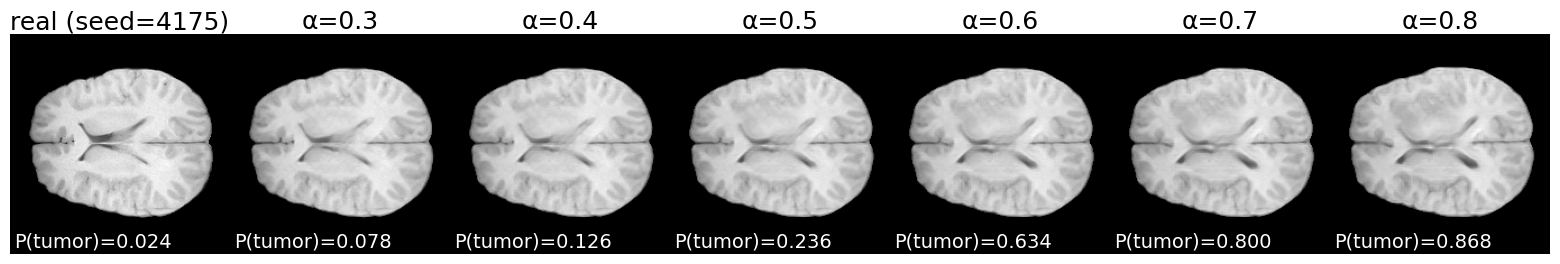

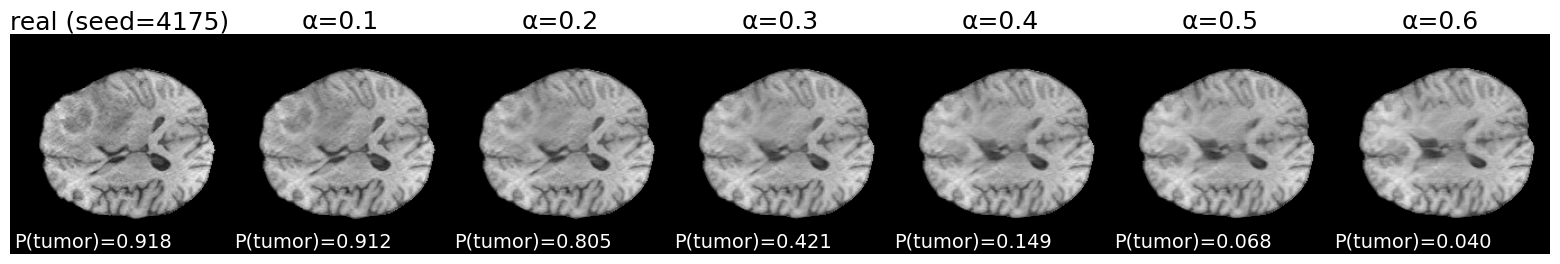

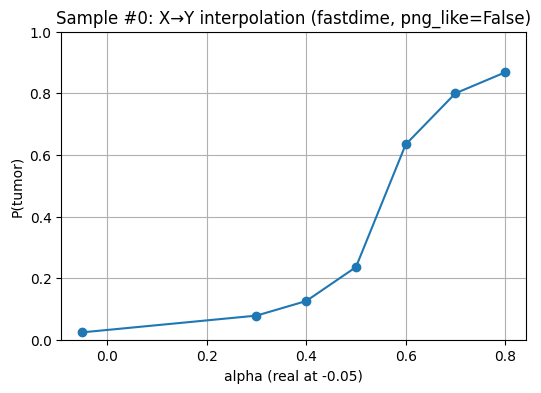

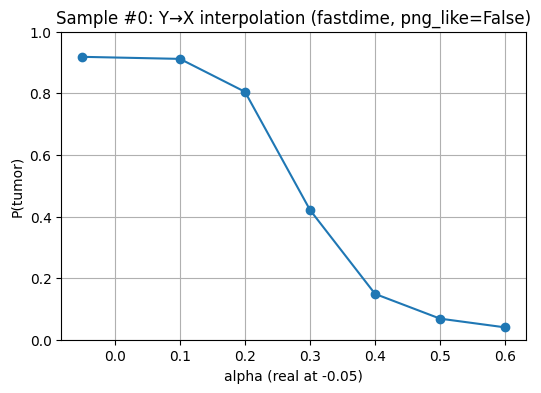

In [56]:
import os
import sys
from pathlib import Path

import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
from tqdm import tqdm

# ============================================================
# 0) Import your interp_utils
#    (把 UTILS_PARENT 改成 interp_utils 文件夹所在的父目录)
# ============================================================
UTILS_PARENT = Path("/home/ids/yuhe/Projects/CA_with_GAN/3_code/styleGAN").resolve()
if str(UTILS_PARENT) not in sys.path:
    sys.path.insert(0, str(UTILS_PARENT))

from interp_utils import (
    load_timm_binary_classifier,
    load_fastdime_classifier,
    score_alpha_series,
)

# ============================================================
# 1) Load classifier (CHOOSE ONE)
# ============================================================

# ---- Switch here ----
CLS_BACKEND = "fastdime"      # "timm" or "fastdime"
PNG_LIKE   = False        # timm only: False=tensor-direct, True=png-like quant
T_VAL      = 0            # fastdime needs t; timm ignores it

if CLS_BACKEND == "timm":
    data_name  = "bratsHT_new"
    model_type = "densenet121"  # densenet121 / resnet34 / swinv2_large / swinv2_small
    ckpt_pth   = f"/home/ids/yuhe/Projects/CA_with_GAN/3_code/styleGAN/evaluation/image_classification/{data_name}/{model_type}/best_model.pth"

    cls = load_timm_binary_classifier(ckpt_pth, model_type=model_type, img_size=256)
    device = cls.device
    print(f"✅ timm classifier loaded: {model_type} | device={device} | PNG_LIKE={PNG_LIKE}")

elif CLS_BACKEND == "fastdime":
    # 如果你还是想用原来的 fastdime 这套，就在这里填 ckpt/type
    # 你也可以继续用你原来的 load_our_classifier，但这里统一成 interp_utils 的 loader
    cls_type = "densenet"  # "unet_encoder" / "resnet" / "densenet"
    ckpt_map = {
        "unet_encoder": "/home/ids/yuhe/Projects/CA_with_GAN/3_code/FastDiME_Med/records/classifier/brats_2D_256/unet_encoder-42/lightning_logs/version_4/checkpoints/loss-epoch=45-val_loss=0.032.ckpt",
        "resnet":       "/home/ids/yuhe/Projects/CA_with_GAN/3_code/FastDiME_Med/records/classifier/brats_2D_256/resnet-42/lightning_logs/version_2/checkpoints/loss-epoch=49-val_loss=0.098.ckpt",
        "densenet":     "/home/ids/yuhe/Projects/CA_with_GAN/3_code/FastDiME_Med/records/classifier/brats_2D_256/densenet-42/lightning_logs/version_0/checkpoints/loss-epoch=49-val_loss=0.214.ckpt",
    }
    cls_ckpt = ckpt_map[cls_type]

    cls = load_fastdime_classifier(cls_ckpt=cls_ckpt, cls_type=cls_type)
    device = cls.device
    print(f"✅ fastdime classifier loaded: {cls_type} | device={device}")

else:
    raise ValueError("CLS_BACKEND must be 'timm' or 'fastdime'")

# ============================================================
# 2) Seed + data paths
#    (get_random_seeds / configure_Seg_datasets / sfe_model 都假设你已经在 notebook 里定义好了)
# ============================================================

seed = get_random_seeds()
print("seed:", seed)
seed = 4175
bg_path = "/home/ids/yuhe/Projects/CA_with_GAN/3_code/styleGAN/Segmentation/data/bratsHT_TUMOR_new/test_X.npy"
t_path  = "/home/ids/yuhe/Projects/CA_with_GAN/3_code/styleGAN/Segmentation/data/bratsHT_TUMOR_new/test_Y.npy"

test_bg_dataloader, test_t_dataloader = configure_Seg_datasets(
    sfe_model.config, seed=seed, shuffle=True, bg_path=bg_path, t_path=t_path
)

# ============================================================
# 3) Alpha range
# ============================================================
num_steps = 11

# alphas_x = torch.linspace(0, 1, steps=num_steps, device=device)
# alphas_y = alphas_x.clone()
alphas_x = torch.tensor([0.3, 0.4, 0.5, 0.6, 0.7, 0.8], device=device)
alphas_y = torch.tensor([0.1, 0.2, 0.3, 0.4, 0.5, 0.6], device=device)

titles_x = [f"real (seed={seed})"] + [f"α={a:.1f}" for a in alphas_x.detach().cpu()]
titles_y = [f"real (seed={seed})"] + [f"α={a:.1f}" for a in alphas_y.detach().cpu()]

# ============================================================
# 4) Utils: infinite target loader
# ============================================================
def infinite_loader(dataloader):
    while True:
        for batch in dataloader:
            yield batch

t_iter = infinite_loader(test_t_dataloader)

# ============================================================
# 5) Save one visual sample only
# ============================================================
VIS_GLOBAL_INDEX = 0
vis_recon_X_alpha = None  # list of [1,C,256,256]
vis_recon_Y_alpha = None
vis_probs_x = None        # [num_steps+1]
vis_probs_y = None

# ============================================================
# 6) Run interpolation scoring (X2Y / Y2X)
# ============================================================
all_probs_x2y = []
all_probs_y2x = []

global_idx = 0

# 你之前写了 classifier.eval()；现在 cls 是 bundle，用 cls.model.eval()
with torch.inference_mode():
    sfe_model.method.train()     # 你之前说 pipeline 可能要求 train mode
    cls.model.eval()

    for batch_idx, batch_bg in tqdm(enumerate(test_bg_dataloader), total=len(test_bg_dataloader)):
        X = batch_bg.to(device).float()
        Y = next(t_iter).to(device).float()

        # ---- align Y batch size to X ----
        Bx, By = X.size(0), Y.size(0)
        if By < Bx:
            reps = (Bx + By - 1) // By
            Y = Y.repeat(reps, 1, 1, 1)[:Bx]
        else:
            Y = Y[:Bx]

        # resize
        X_resh = F.interpolate(X, size=(256, 256), mode="bilinear", align_corners=False)
        Y_resh = F.interpolate(Y, size=(256, 256), mode="bilinear", align_corners=False)

        # latents
        c_x, s_x, c_y, s_y = get_latents_cs(X_resh, Y_resh, sfe_model)

        # deltas
        delta_x2y = calculate_delta_by_latent(c_x + s_x, c_x + s_y, sfe_model)
        delta_y2x = calculate_delta_by_latent(c_y + s_y, c_y + s_x, sfe_model)

        # whether this batch contains the global vis index
        need_vis_in_this_batch = (VIS_GLOBAL_INDEX >= global_idx) and (VIS_GLOBAL_INDEX < global_idx + Bx)
        local_i = (VIS_GLOBAL_INDEX - global_idx) if need_vis_in_this_batch else None

        # ---- score alpha series with unified API ----
        probs_x2y_t, vis_x = score_alpha_series(
            base_imgs=X_resh,
            delta=delta_x2y,
            alphas=alphas_x,
            recon_by_delta_fn=recon_by_delta,
            classifier=cls,
            t_val=T_VAL,
            png_like=PNG_LIKE,
            keep_index_in_batch=local_i,
            recon_kwargs=dict(sfe_model=sfe_model),
        )

        probs_y2x_t, vis_y = score_alpha_series(
            base_imgs=Y_resh,
            delta=delta_y2x,
            alphas=alphas_y,
            recon_by_delta_fn=recon_by_delta,
            classifier=cls,
            t_val=T_VAL,
            png_like=PNG_LIKE,
            keep_index_in_batch=local_i,
            recon_kwargs=dict(sfe_model=sfe_model),
        )

        probs_x_batch = probs_x2y_t.detach().cpu().numpy()  # [B, num_steps+1]
        probs_y_batch = probs_y2x_t.detach().cpu().numpy()

        all_probs_x2y.append(probs_x_batch)
        all_probs_y2x.append(probs_y_batch)

        if need_vis_in_this_batch:
            vis_recon_X_alpha = vis_x
            vis_recon_Y_alpha = vis_y
            vis_probs_x = probs_x_batch[local_i].copy()
            vis_probs_y = probs_y_batch[local_i].copy()

        global_idx += Bx

        # DEBUG: 只跑一个 batch 就 break（你原来就有）
        break

all_probs_x2y = np.concatenate(all_probs_x2y, axis=0)
all_probs_y2x = np.concatenate(all_probs_y2x, axis=0)

print("✅ all_probs_x2y:", all_probs_x2y.shape)
print("✅ all_probs_y2x:", all_probs_y2x.shape)

# ============================================================
# 7) Visualization helpers
# ============================================================
def crop_image(img, w_l=0, w_r=0, h_top=0, h_bot=0):
    w, h = img.size
    return img.crop((w_l, h_top, w - w_r, h - h_bot))

def tensor_to_cropped_img(t, crop_cfg):
    """
    t: tensor [C,H,W] in [-1,1]
    """
    t = ((t.clamp(-1, 1) + 1) / 2).detach().cpu()
    if t.shape[0] == 1:
        img = (t.squeeze(0).numpy() * 255).astype("uint8")
        pil_img = Image.fromarray(img, mode="L")
    else:
        img = (t.permute(1, 2, 0).numpy() * 255).astype("uint8")
        pil_img = Image.fromarray(img)
    pil_img = crop_image(pil_img, **crop_cfg)
    return np.array(pil_img)

def add_prob_overlay(ax, prob, fontsize=14):
    ax.text(
        0.02, 0.10, f"P(tumor)={prob:.3f}",
        transform=ax.transAxes,
        ha="left", va="top",
        fontsize=fontsize,
        color="white",
        bbox=dict(facecolor="black", alpha=0.6, pad=2, edgecolor="none"),
    )

# crop config（跟你原来一致）
h = 5
crop_cfg = dict(w_l=30 + h, w_r=30 - h, h_top=30, h_bot=30)
%matplotlib inline
# --- single sample visualization ---
if vis_recon_X_alpha is not None and vis_probs_x is not None:
    num_images = len(vis_recon_X_alpha)
    col_spacing = 0.0
    total_width = 1.0
    img_width = (total_width - (num_images - 1) * col_spacing) / num_images
    title_height = 0.10

    # X row
    fig_x = plt.figure(figsize=(num_images * 2.2, 3.0))
    for i in range(num_images):
        left = i * (img_width + col_spacing)
        ax = fig_x.add_axes([left, 0, img_width, 1 - title_height])

        img = tensor_to_cropped_img(vis_recon_X_alpha[i][0], crop_cfg)
        ax.imshow(img)
        ax.axis("off")
        ax.set_title(titles_x[i], fontsize=18, pad=2)
        add_prob_overlay(ax, vis_probs_x[i], fontsize=14)
    plt.show()

    # Y row
    fig_y = plt.figure(figsize=(num_images * 2.2, 3.0))
    for i in range(num_images):
        left = i * (img_width + col_spacing)
        ax = fig_y.add_axes([left, 0, img_width, 1 - title_height])

        img = tensor_to_cropped_img(vis_recon_Y_alpha[i][0], crop_cfg)
        ax.imshow(img)
        ax.axis("off")
        ax.set_title(titles_y[i], fontsize=18, pad=2)
        add_prob_overlay(ax, vis_probs_y[i], fontsize=14)
    plt.show()

    # curves
    x_axis = np.concatenate(([-0.05], alphas_x.detach().cpu().numpy()))
    y_axis = np.concatenate(([-0.05], alphas_y.detach().cpu().numpy()))

    plt.figure(figsize=(6,4))
    plt.plot(x_axis, vis_probs_x, marker="o")
    plt.ylim(0, 1)
    plt.xlabel("alpha (real at -0.05)")
    plt.ylabel("P(tumor)")
    plt.title(f"Sample #{VIS_GLOBAL_INDEX}: X→Y interpolation ({CLS_BACKEND}, png_like={PNG_LIKE})")
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(6,4))
    plt.plot(y_axis, vis_probs_y, marker="o")
    plt.ylim(0, 1)
    plt.xlabel("alpha (real at -0.05)")
    plt.ylabel("P(tumor)")
    plt.title(f"Sample #{VIS_GLOBAL_INDEX}: Y→X interpolation ({CLS_BACKEND}, png_like={PNG_LIKE})")
    plt.grid(True)
    plt.show()

# --- mean curves (optional) ---
# mean_x = all_probs_x2y.mean(axis=0)
# mean_y = all_probs_y2x.mean(axis=0)
# x_axis = np.concatenate(([-0.05], alphas_x.detach().cpu().numpy()))
# plt.figure(figsize=(6,4))
# plt.plot(x_axis, mean_x, marker="o")
# plt.ylim(0, 1)
# plt.xlabel("alpha (real at -0.05)")
# plt.ylabel("P(tumor)")
# plt.title(f"MEAN over all bg: X→Y ({CLS_BACKEND}, png_like={PNG_LIKE})")
# plt.grid(True)
# plt.show()
#
# plt.figure(figsize=(6,4))
# plt.plot(x_axis, mean_y, marker="o")
# plt.ylim(0, 1)
# plt.xlabel("alpha (real at -0.05)")
# plt.ylabel("P(tumor)")
# plt.title(f"MEAN over all bg: Y→X ({CLS_BACKEND}, png_like={PNG_LIKE})")
# plt.grid(True)
# plt.show()

# 11962  1352 10166 16903 

# 2315 6339